In [1]:
!unzip "archive (3).zip"

Archive:  archive (3).zip
  inflating: House Price Prediction Dataset.csv  


House Price Prediction is a machine learning regression problem where the goal is to predict the price of a house based on various features such as area, number of bedrooms, bathrooms, and location. This project uses machine learning algorithms to analyze housing data and estimate property prices.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

The objective of this project is to develop a predictive model that estimates house prices based on property features. By analyzing historical housing data, the model learns patterns that influence property value.

In [3]:
df = pd.read_csv("House Price Prediction Dataset.csv")

df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


The dataset contains information about houses including area, number of bedrooms, number of bathrooms, number of floors, construction year, location, condition, and availability of garage. The target variable in this dataset is Price.

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


Data preprocessing is an important step in machine learning. In this project, categorical variables such as location and condition are converted into numerical values using one-hot encoding. Missing values are handled and unnecessary columns are removed to prepare the data for model training.

In [6]:
df.columns

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')

In [7]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [8]:
X = pd.get_dummies(X, drop_first=True)

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [22]:
import pickle

# save the trained model
pickle.dump(model, open("house_price_model.pkl", "wb"))

In [11]:
y_pred = model.predict(X_test)

In [12]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 279785.21069002635
R2 Score: -0.006181784611834162


In [13]:
model.fit(X_train, y_train)

LinearRegression()

In [14]:
print(model)

LinearRegression()


In [15]:
y_pred = model.predict(X_test)

print(y_pred[:5])

[511317.73109931 557359.55652936 482838.34523391 540695.6411198
 549288.50244107]


In [16]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 279785.21069002635
R2 Score: -0.006181784611834162


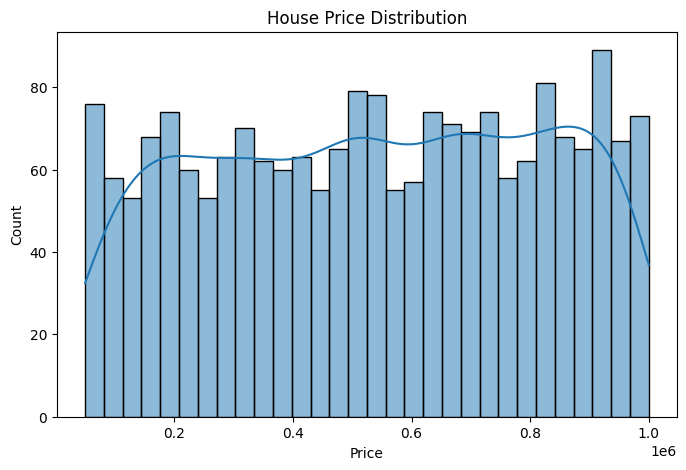

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=30, kde=True)
plt.title("House Price Distribution")
plt.show()

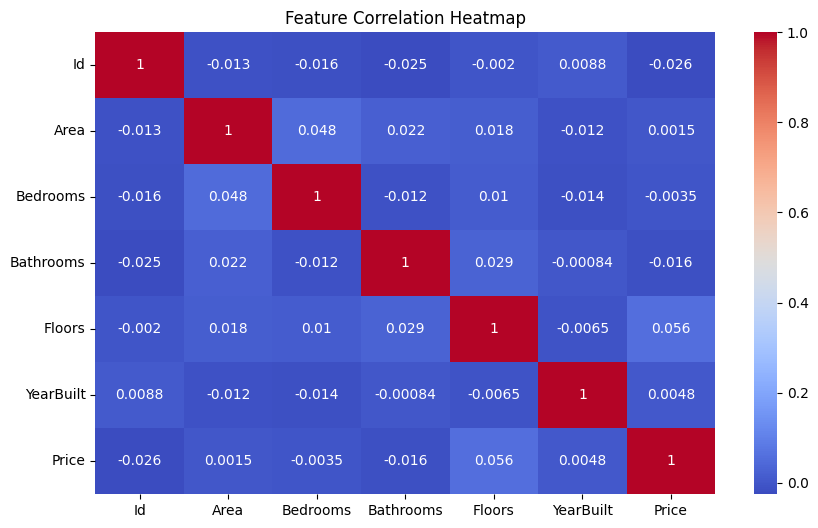

In [19]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

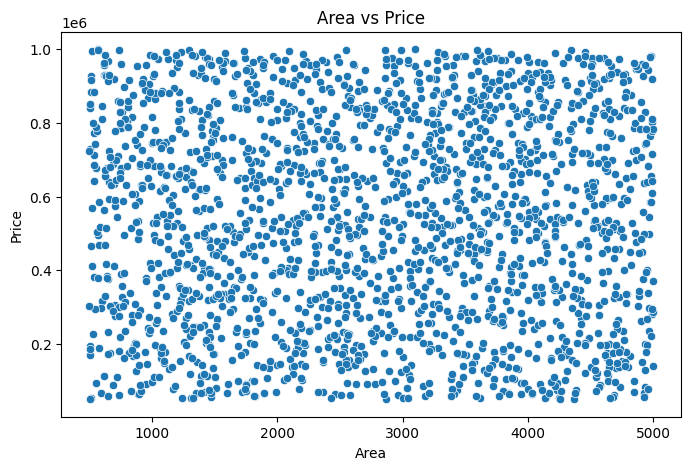

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Area'], y=df['Price'])
plt.title("Area vs Price")
plt.show()